In [1]:
# import requests
import pandas as pd
import numpy as np
# from scipy.stats import entropy
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller  
from statsmodels.graphics.tsaplots import plot_acf#, plot_pacf
# from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import root_mean_squared_error , mean_absolute_error , mean_absolute_percentage_error          

import holidays

# pd.options.display.float_format = '{:,.2f}'.format
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

In [2]:
df = pd.read_csv("dataset_FINAL_all_variables.csv")

In [3]:
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')


In [4]:
selected_cols = ['month', 
                          'employment_rate_diff', 
                         'industry_production_prices_diff',
                         'companies_trust', 
                        # 'rolling_mean_3m', 
                        'rolling_mean_6m',
                        'rolling_mean_12m', 
                        # 'rolling_std_12m', 
                        'PCA_labour_market_1',
                        'PCA_labour_market_2', 
                        'PCA_price_energy_1', 
                         'PCA_price_energy_2'
                        ]                        

In [5]:
df_selected = df[selected_cols]
df_selected.head(5)

,month,employment_rate_diff,industry_production_prices_diff,companies_trust,rolling_mean_6m,rolling_mean_12m,PCA_labour_market_1,PCA_labour_market_2,PCA_price_energy_1,PCA_price_energy_2
date,,,,,,,,,,
2014-02-01,2,1.12,0.0,87.3,0.498333,0.071667,1.010529,0.008249,0.055560,0.130186
2014-03-01,3,0.17,-0.2,89.2,0.155000,0.045000,1.324103,0.005868,0.035844,0.097364
2014-04-01,4,-1.24,-0.2,88.3,-0.003333,0.026667,-2.753315,0.000535,0.034115,0.079195
2014-05-01,5,2.21,-0.1,87.6,-0.066667,0.039167,1.921402,0.008001,0.045199,0.066056
2014-06-01,6,-0.40,0.2,89.3,-0.158333,-0.027500,-1.471143,-0.014951,0.041625,0.071715


# 1. Fixed Term

## Training

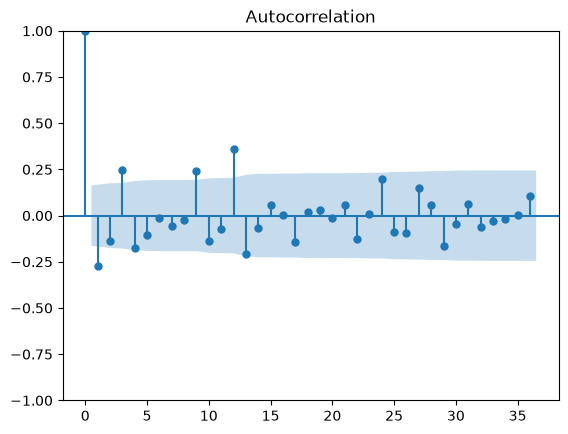

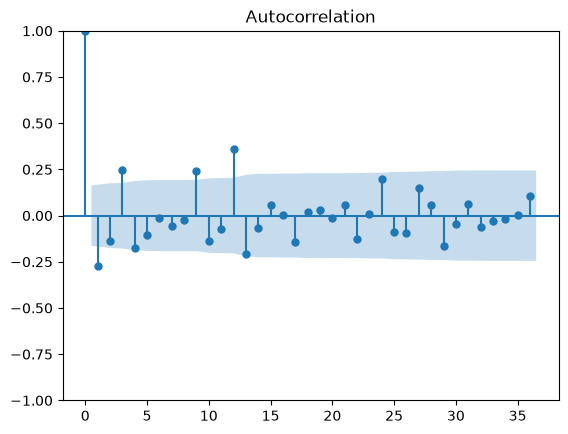

In [6]:
feature = 'employment_rate_diff'

width = 10
height = 5

plot_acf(df[feature],lags=36,alpha=0.05 )

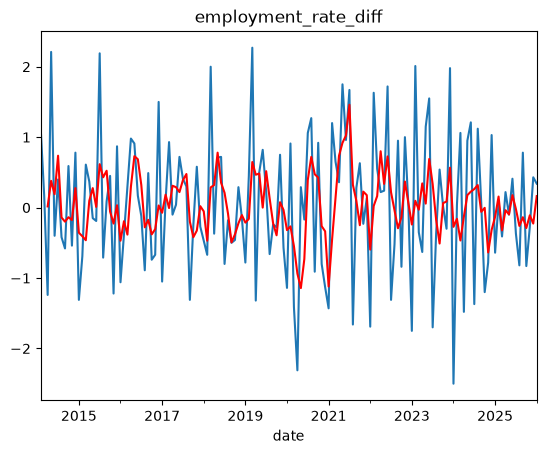

In [7]:
plt.title(feature)
rolling = df[feature].rolling(window=3) #df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df[feature].plot()
rolling_mean.plot(color='red')
plt.show()

In [8]:
df_train = df[feature][5:-12]
df_test = df[feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 0))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [9]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 0.8
mae_test: 0.42
mape_train: 0.98%
mape_test: 0.98%


### Forecasting

In [10]:
h = 12
model = ARIMA( endog=df[feature]
              , order=(0, 0, 1))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_fixed_term = pd.DataFrame({f"{feature}": fcst})
df_fcst_fixed_term

,employment_rate_diff
2026-02-01,-0.089457
2026-03-01,0.039906
2026-04-01,0.039906
2026-05-01,0.039906
2026-06-01,0.039906
2026-07-01,0.039906
2026-08-01,0.039906
2026-09-01,0.039906
2026-10-01,0.039906
2026-11-01,0.039906


In [11]:
# df_selected = pd.concat([df_selected, df_fcst], axis = 0)
# df_selected

# 2. employment_rate

### Training

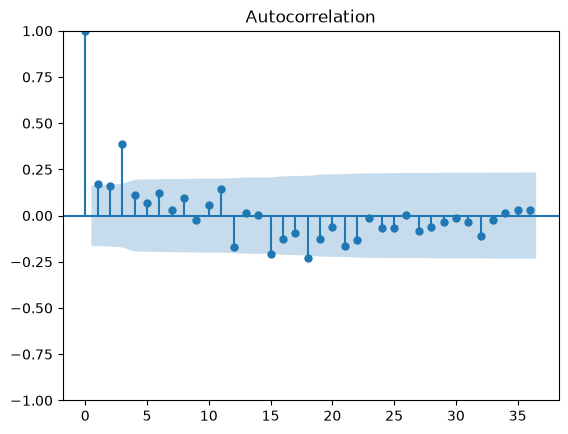

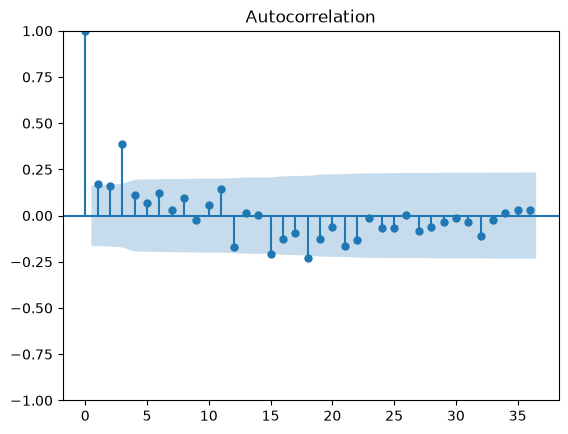

In [12]:
feature = 'industry_production_prices_diff'

width = 10
height = 5

plot_acf(df[feature],lags=36,alpha=0.05 )

In [13]:
test_staticist = adfuller(df[feature])[0]
adf_criticatical_value_5perc = adfuller(df[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df[f'{feature}_diff'] = df[feature] - df[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')    

-3.93 < -2.88 ==> The time series is STATIONARY


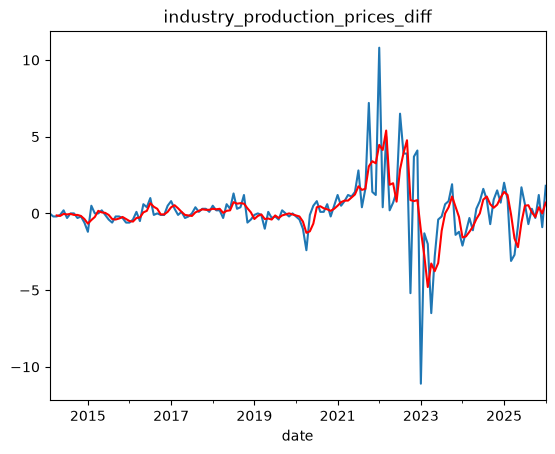

In [14]:
from matplotlib import pyplot
#series = read_csv('daily-total-female-births.csv', header=0, index_col=0)
# Tail-rolling average transform
plt.title(feature)
rolling = df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df[feature].plot()
rolling_mean.plot(color='red')
pyplot.show()

In [15]:
df_train = df[feature][5:-12]
df_test = df[feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 13))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [16]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 0.98
mae_test: 1.49
mape_train: 80969184739735.19%
mape_test: 1.3%


### Forecasting

In [17]:
h = 12
model = ARIMA( endog=df[feature]
              , order=(0, 0, 13))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_employment_rate = pd.DataFrame({f"{feature}": fcst})
df_fcst_employment_rate

,industry_production_prices_diff
2026-02-01,0.074063
2026-03-01,-0.534842
2026-04-01,0.788764
2026-05-01,1.603578
2026-06-01,-0.286812
2026-07-01,0.280216
2026-08-01,0.468329
2026-09-01,0.133576
2026-10-01,0.493602
2026-11-01,0.039592


# 3. youth_employment_rate

### Training

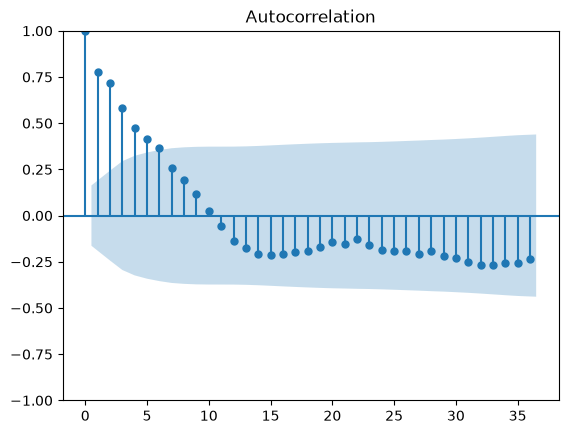

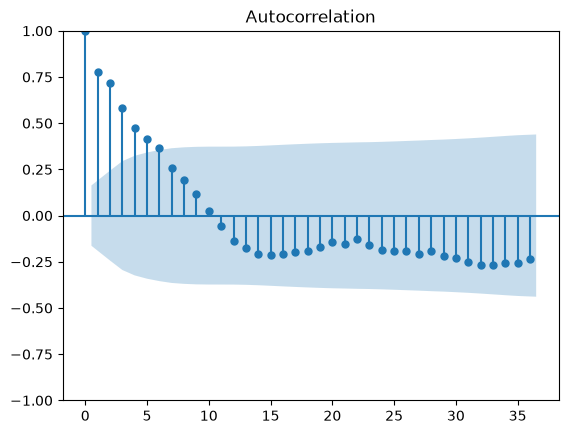

In [18]:
feature = 'companies_trust'

width = 10
height = 5

plot_acf(df[feature],lags=36,alpha=0.05 )

In [19]:
test_staticist = adfuller(df[feature])[0]
adf_criticatical_value_5perc = adfuller(df[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df[f'{feature}_diff'] = df[feature] - df[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')    

-3.11 < -2.88 ==> The time series is STATIONARY


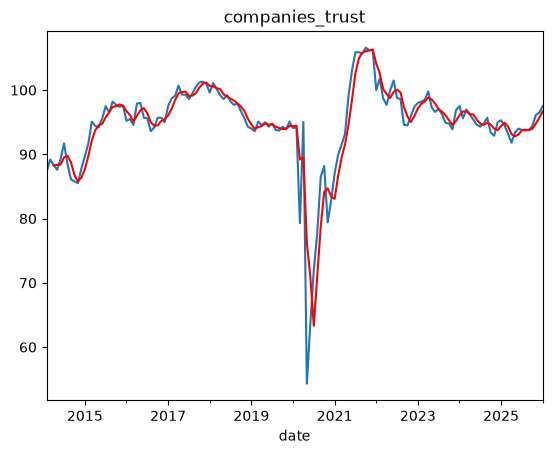

In [20]:
from matplotlib import pyplot
#series = read_csv('daily-total-female-births.csv', header=0, index_col=0)
# Tail-rolling average transform
plt.title(feature)
rolling = df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df[feature].plot()
rolling_mean.plot(color='red')
pyplot.show()

In [21]:
df_train = df[feature][5:-12]
df_test = df[feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 12))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [22]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 1.89
mae_test: 1.53
mape_train: 0.02%
mape_test: 0.02%


### Forecasting

In [23]:
h = 12
model = ARIMA( endog=df[feature]
              , order=(0, 0, 12))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_youth_employment_rate = pd.DataFrame({f"{feature}": fcst})
df_fcst_youth_employment_rate

,companies_trust
2026-02-01,97.117967
2026-03-01,97.119872
2026-04-01,96.517953
2026-05-01,96.336419
2026-06-01,96.374114
2026-07-01,96.456406
2026-08-01,96.273113
2026-09-01,96.270224
2026-10-01,96.154097
2026-11-01,95.814460


# 4. industry_production_prices

### Training

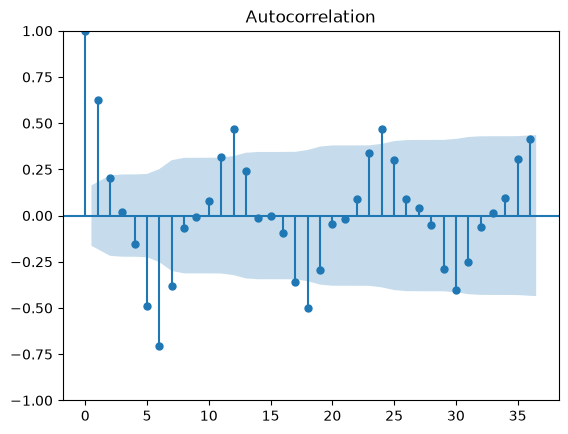

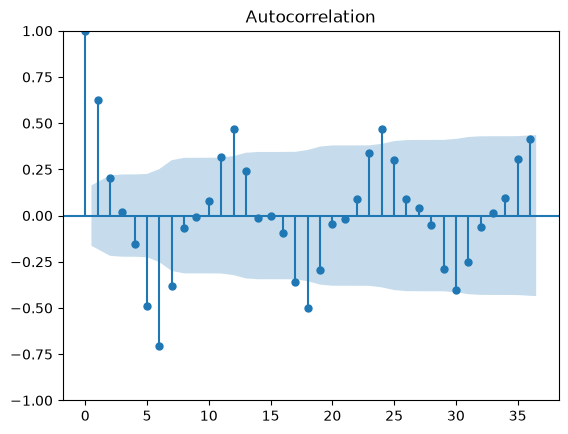

In [24]:
feature = 'rolling_mean_6m'

width = 10
height = 5

plot_acf(df[feature],lags=36,alpha=0.05 )

In [25]:
test_staticist = adfuller(df[feature])[0]
adf_criticatical_value_5perc = adfuller(df[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df[f'{feature}_diff'] = df[feature] - df[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')    

-5.0 < -2.88 ==> The time series is STATIONARY


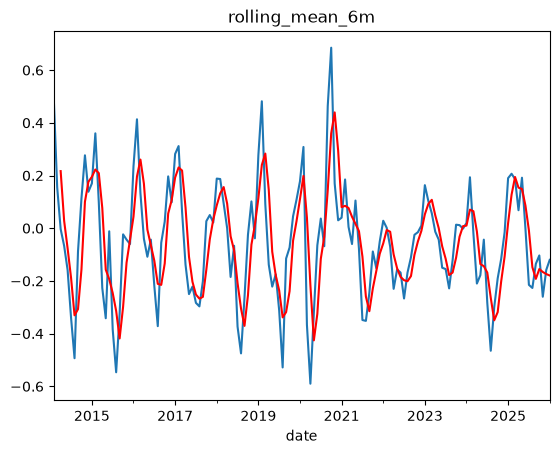

In [26]:
from matplotlib import pyplot
#series = read_csv('daily-total-female-births.csv', header=0, index_col=0)
# Tail-rolling average transform
plt.title(feature)
rolling = df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df[feature].plot()
rolling_mean.plot(color='red')
pyplot.show()

In [27]:
df_train = df[feature][5:-12]
df_test = df[feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 12))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [28]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 0.08
mae_test: 0.1
mape_train: 1560951613163.77%
mape_test: 4.41%


### Forecasting

In [29]:
h = 12
model = ARIMA( endog=df[feature]
              , order=(0, 0, 12))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_industry_production_prices = pd.DataFrame({f"{feature}": fcst})
df_fcst_industry_production_prices

,rolling_mean_6m
2026-02-01,-0.050401
2026-03-01,-0.045746
2026-04-01,0.040409
2026-05-01,0.030402
2026-06-01,0.048184
2026-07-01,0.158880
2026-08-01,0.088353
2026-09-01,0.016247
2026-10-01,-0.022718
2026-11-01,-0.021367


# 5. diesel_price

### Training

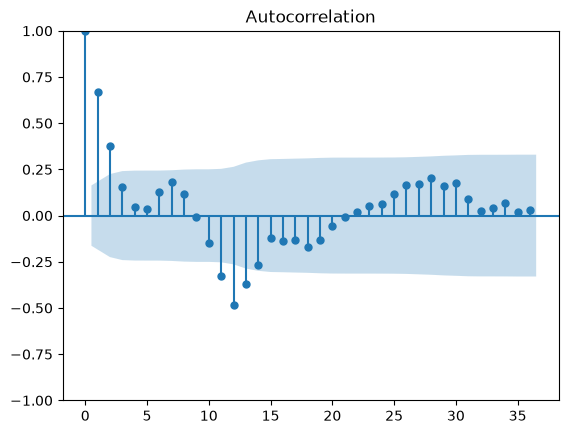

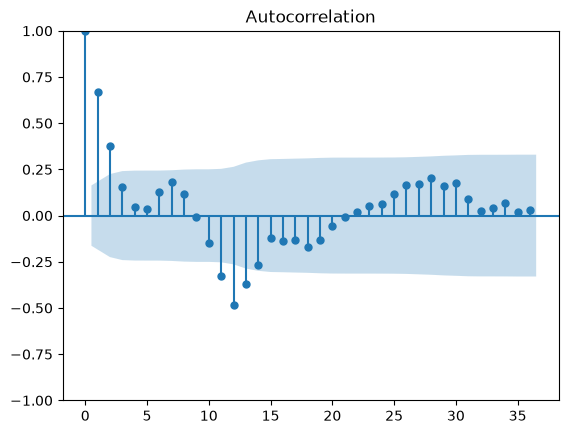

In [30]:
feature = 'rolling_mean_12m'

width = 10
height = 5

plot_acf(df[feature],lags=36,alpha=0.05 ) 

In [31]:
test_staticist = adfuller(df[feature])[0]
adf_criticatical_value_5perc = adfuller(df[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df[f'{feature}_diff'] = df[feature] - df[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')    

-3.55 < -2.88 ==> The time series is STATIONARY


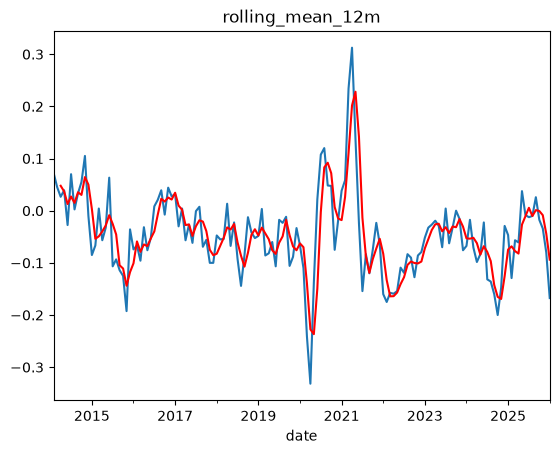

In [32]:
from matplotlib import pyplot
#series = read_csv('daily-total-female-births.csv', header=0, index_col=0)
# Tail-rolling average transform
plt.title(feature)
rolling = df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df[feature].plot()
rolling_mean.plot(color='red')
pyplot.show()

In [33]:
df_train = df[feature][5:-12]
df_test = df[feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 11))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [34]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 0.04
mae_test: 0.06
mape_train: 768803279910.01%
mape_test: 3.11%


### Forecasting

In [35]:
h = 12
model = ARIMA( endog=df[feature]
              , order=(0, 0, 12))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_diesel_price = pd.DataFrame({f"{feature}": fcst})
df_fcst_diesel_price

,rolling_mean_12m
2026-02-01,-0.144406
2026-03-01,-0.132704
2026-04-01,-0.132468
2026-05-01,-0.213010
2026-06-01,-0.159123
2026-07-01,-0.136599
2026-08-01,-0.177421
2026-09-01,-0.169206
2026-10-01,-0.094444
2026-11-01,-0.108111


# variabile X

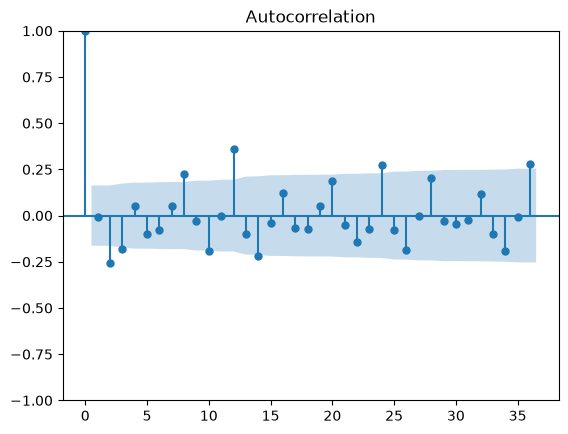

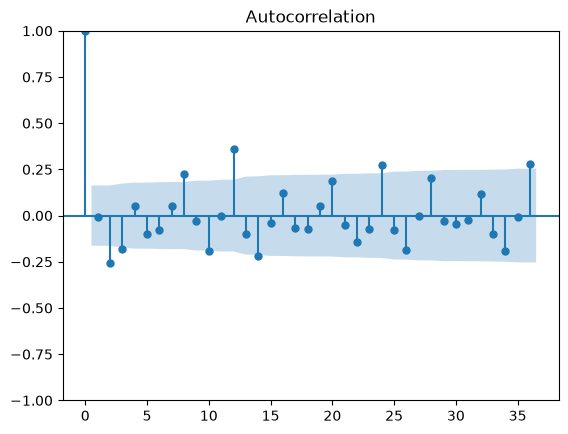

In [36]:
feature = 'PCA_labour_market_1'

width = 10
height = 5

plot_acf(df[feature],lags=36,alpha=0.05 ) 

In [37]:
test_staticist = adfuller(df[feature])[0]
adf_criticatical_value_5perc = adfuller(df[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df[f'{feature}_diff'] = df[feature] - df[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')    

-2.78 > -2.88 ==> The time series is NON stationary


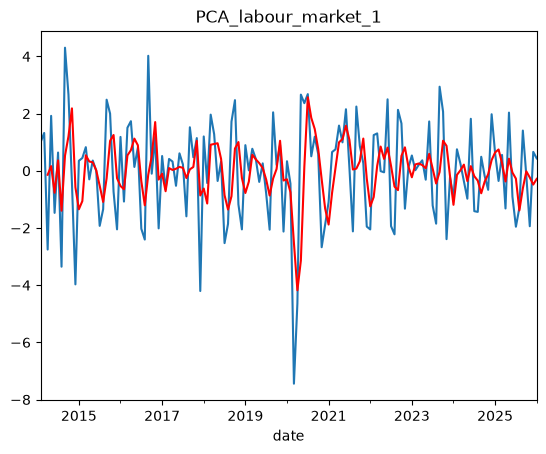

In [38]:
# from matplotlib import pyplot
#series = read_csv('daily-total-female-births.csv', header=0, index_col=0)
# Tail-rolling average transform
plt.title(feature)
rolling = df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df[feature].plot()
rolling_mean.plot(color='red')
pyplot.show()

In [39]:
df_train = df[feature][5:-12]
df_test = df[feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 11))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [40]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 1.16
mae_test: 1.09
mape_train: 4.71%
mape_test: 1.04%


In [41]:
h = 12
model = ARIMA( endog=df[feature]
              , order=(0, 0, 12))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_diesel_price = pd.DataFrame({f"{feature}": fcst})
df_fcst_diesel_price

,PCA_labour_market_1
2026-02-01,0.256510
2026-03-01,-0.381776
2026-04-01,-0.392009
2026-05-01,0.862010
2026-06-01,0.105277
2026-07-01,-0.696071
2026-08-01,-0.282965
2026-09-01,0.423404
2026-10-01,0.187028
2026-11-01,-0.357752


# var

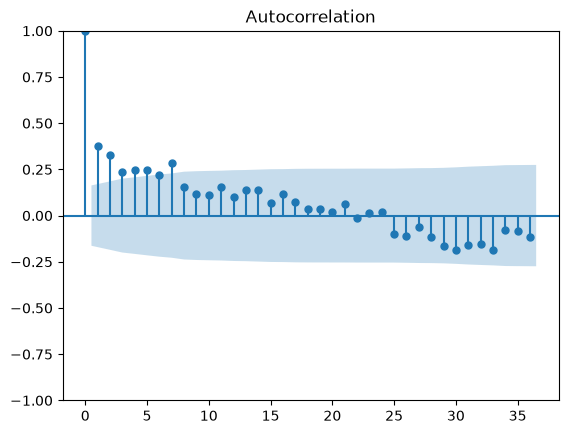

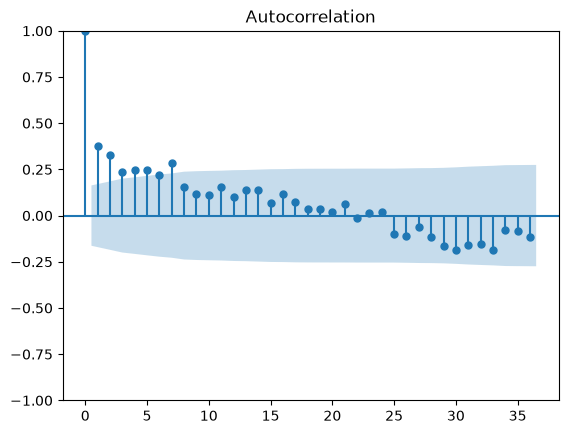

In [42]:
feature = 'PCA_labour_market_2'

width = 10
height = 5

plot_acf(df[feature],lags=36,alpha=0.05 ) 

In [43]:
test_staticist = adfuller(df[feature])[0]
adf_criticatical_value_5perc = adfuller(df[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df[f'{feature}_diff'] = df[feature] - df[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')    

-5.28 < -2.88 ==> The time series is STATIONARY


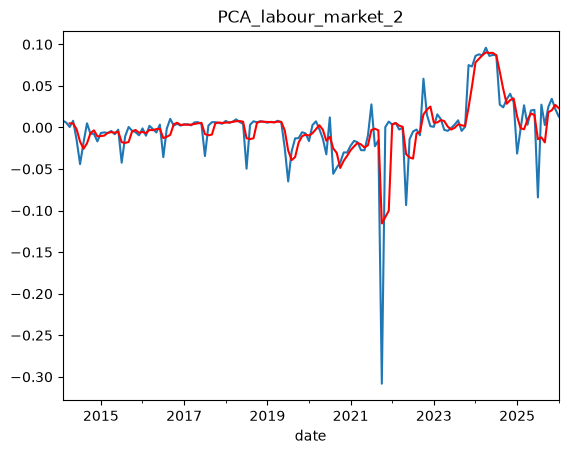

In [44]:
# from matplotlib import pyplot
#series = read_csv('daily-total-female-births.csv', header=0, index_col=0)
# Tail-rolling average transform
plt.title(feature)
rolling = df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df[feature].plot()
rolling_mean.plot(color='red')
pyplot.show()

In [45]:
df_train = df[feature][5:-12]
df_test = df[feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 11))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [46]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 0.02
mae_test: 0.03
mape_train: 3.13%
mape_test: 1.33%


In [47]:
h = 12
model = ARIMA( endog=df[feature]
              , order=(0, 0, 12))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_diesel_price = pd.DataFrame({f"{feature}": fcst})
df_fcst_diesel_price

,PCA_labour_market_2
2026-02-01,-0.003330
2026-03-01,0.011222
2026-04-01,0.014441
2026-05-01,0.009858
2026-06-01,0.001114
2026-07-01,0.011606
2026-08-01,0.000768
2026-09-01,0.000407
2026-10-01,0.002620
2026-11-01,0.001290


# var

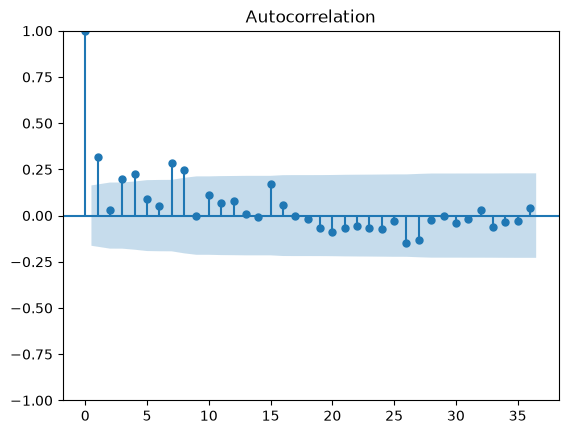

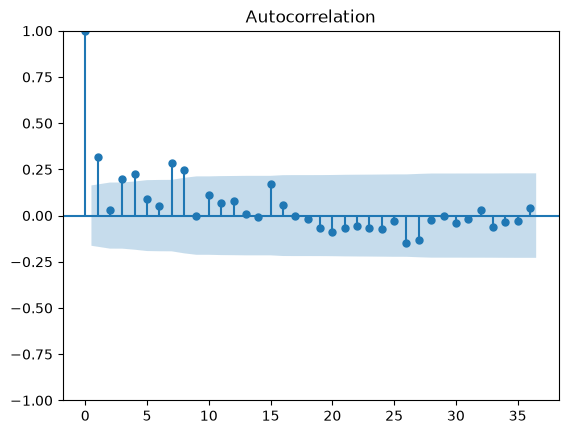

In [48]:
feature = 'PCA_price_energy_1'

width = 10
height = 5

plot_acf(df[feature],lags=36,alpha=0.05 ) 

In [49]:
test_staticist = adfuller(df[feature])[0]
adf_criticatical_value_5perc = adfuller(df[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df[f'{feature}_diff'] = df[feature] - df[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')    

-2.64 > -2.88 ==> The time series is NON stationary


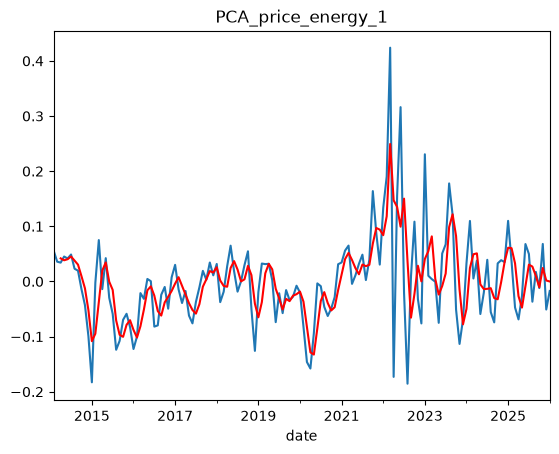

In [50]:
# from matplotlib import pyplot
#series = read_csv('daily-total-female-births.csv', header=0, index_col=0)
# Tail-rolling average transform
plt.title(feature)
rolling = df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df[feature].plot()
rolling_mean.plot(color='red')
pyplot.show()

In [51]:
df_train = df[feature][5:-12]
df_test = df[feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 11))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [52]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 0.05
mae_test: 0.04
mape_train: 2.54%
mape_test: 1.12%


In [53]:
h = 12
model = ARIMA( endog=df[feature]
              , order=(0, 0, 12))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_diesel_price = pd.DataFrame({f"{feature}": fcst})
df_fcst_diesel_price

,PCA_price_energy_1
2026-02-01,0.021205
2026-03-01,-0.014086
2026-04-01,-0.010971
2026-05-01,0.009162
2026-06-01,-0.000619
2026-07-01,0.017399
2026-08-01,-0.030348
2026-09-01,0.016505
2026-10-01,-0.007219
2026-11-01,0.003494


# var

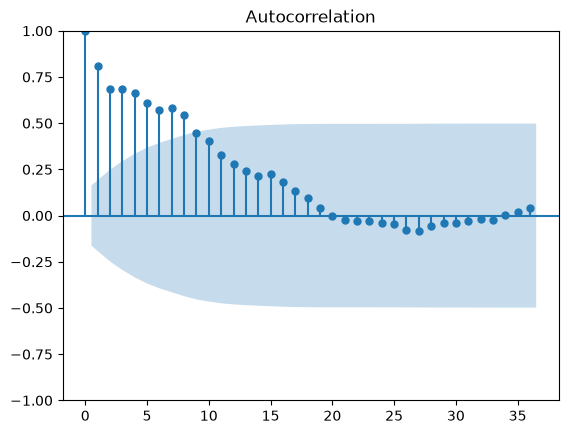

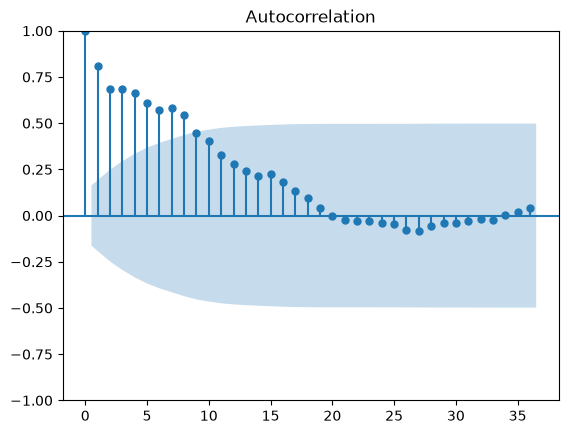

In [54]:
feature = 'PCA_price_energy_2'

width = 10
height = 5

plot_acf(df[feature],lags=36,alpha=0.05 ) 

In [55]:
test_staticist = adfuller(df[feature])[0]
adf_criticatical_value_5perc = adfuller(df[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df[f'{feature}_diff'] = df[feature] - df[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')    

-2.56 > -2.88 ==> The time series is NON stationary


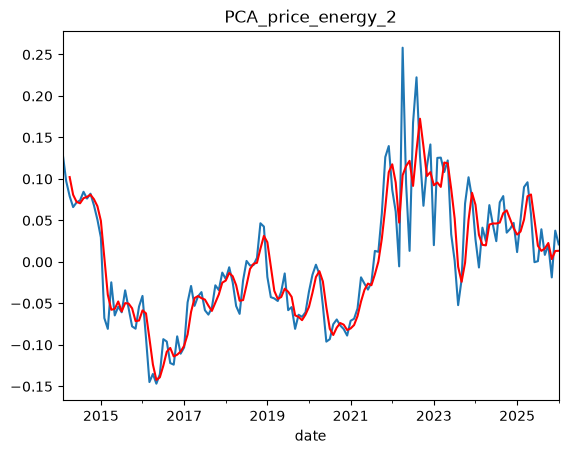

In [56]:
# from matplotlib import pyplot
#series = read_csv('daily-total-female-births.csv', header=0, index_col=0)
# Tail-rolling average transform
plt.title(feature)
rolling = df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df[feature].plot()
rolling_mean.plot(color='red')
pyplot.show()

In [57]:
df_train = df[feature][5:-12]
df_test = df[feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 11))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [58]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 0.03
mae_test: 0.05
mape_train: 0.84%
mape_test: 8.79%


In [59]:
h = 12
model = ARIMA( endog=df[feature]
              , order=(0, 0, 12))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_diesel_price = pd.DataFrame({f"{feature}": fcst})
df_fcst_diesel_price

,PCA_price_energy_2
2026-02-01,-0.002167
2026-03-01,-0.006371
2026-04-01,-0.007769
2026-05-01,-0.020998
2026-06-01,-0.007563
2026-07-01,-0.011163
2026-08-01,0.010330
2026-09-01,-0.009008
2026-10-01,0.005703
2026-11-01,0.002474


# GENERATE FINAL DATASET

# Working days

In [60]:
year = 2026

# Italy holidays
it_holidays = holidays.country_holidays("IT", years=[year])

# Generate all days in the year
# dates = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31")
dates = pd.date_range(start="2026-01-01", end="2027-01-31")

df_days = pd.DataFrame({"date": dates})

# Weekday: Monday=0, Sunday=6
df_days["weekday"] = df_days["date"].dt.weekday

df_days["month_start"] = df_days["date"] - pd.offsets.MonthBegin(1) + pd.offsets.MonthBegin(0)

# Working day if weekday < 5 and not a holiday
df_days["is_working_day"] = (df_days["weekday"] < 5) & (~df_days["date"].isin(it_holidays))

# Count working days per month
monthly_working_days = df_days.groupby(df_days["date"].dt.month)["is_working_day"].sum()

df_days['WorkingDays'] = np.where(df_days['is_working_day']==True, 1, 0)

In [61]:
df_working_days = df_days[df_days['month_start']>'2026-01-01'].groupby('month_start')['WorkingDays'].sum().reset_index().rename(columns={'month_start':'date'}).set_index('date')


In [62]:
df_working_days

,WorkingDays
date,
2026-02-01,20
2026-03-01,23
2026-04-01,22
2026-05-01,21
2026-06-01,22
2026-07-01,22
2026-08-01,22
2026-09-01,22
2026-10-01,21


In [63]:
df_fcst = pd.concat([df_fcst_fixed_term, 
                     df_fcst_employment_rate,
                     df_fcst_youth_employment_rate, 
                     df_fcst_industry_production_prices,
                     df_fcst_diesel_price, 
                     df_working_days], axis = 1)
df_fcst

,employment_rate_diff,industry_production_prices_diff,companies_trust,rolling_mean_6m,PCA_price_energy_2,WorkingDays
2026-02-01,-0.089457,0.074063,97.117967,-0.050401,-0.002167,20
2026-03-01,0.039906,-0.534842,97.119872,-0.045746,-0.006371,23
2026-04-01,0.039906,0.788764,96.517953,0.040409,-0.007769,22
2026-05-01,0.039906,1.603578,96.336419,0.030402,-0.020998,21
2026-06-01,0.039906,-0.286812,96.374114,0.048184,-0.007563,22
2026-07-01,0.039906,0.280216,96.456406,0.158880,-0.011163,22
2026-08-01,0.039906,0.468329,96.273113,0.088353,0.010330,22
2026-09-01,0.039906,0.133576,96.270224,0.016247,-0.009008,22
2026-10-01,0.039906,0.493602,96.154097,-0.022718,0.005703,21
2026-11-01,0.039906,0.039592,95.814460,-0.021367,0.002474,22


In [64]:
df_selected = pd.concat([df_selected, df_fcst], axis = 0)
df_selected

,month,employment_rate_diff,industry_production_prices_diff,companies_trust,rolling_mean_6m,rolling_mean_12m,PCA_labour_market_1,PCA_labour_market_2,PCA_price_energy_1,PCA_price_energy_2,WorkingDays
2014-02-01,2.0,1.120000,0.000000,87.300000,0.498333,0.071667,1.010529,0.008249,0.055560,0.130186,NaN
2014-03-01,3.0,0.170000,-0.200000,89.200000,0.155000,0.045000,1.324103,0.005868,0.035844,0.097364,NaN
2014-04-01,4.0,-1.240000,-0.200000,88.300000,-0.003333,0.026667,-2.753315,0.000535,0.034115,0.079195,NaN
2014-05-01,5.0,2.210000,-0.100000,87.600000,-0.066667,0.039167,1.921402,0.008001,0.045199,0.066056,NaN
2014-06-01,6.0,-0.400000,0.200000,89.300000,-0.158333,-0.027500,-1.471143,-0.014951,0.041625,0.071715,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2026-09-01,NaN,0.039906,0.133576,96.270224,0.016247,NaN,NaN,NaN,NaN,-0.009008,22.0
2026-10-01,NaN,0.039906,0.493602,96.154097,-0.022718,NaN,NaN,NaN,NaN,0.005703,21.0
2026-11-01,NaN,0.039906,0.039592,95.814460,-0.021367,NaN,NaN,NaN,NaN,0.002474,22.0
2026-12-01,NaN,0.039906,0.949258,95.330161,-0.072750,NaN,NaN,NaN,NaN,0.004625,23.0


In [65]:
df_selected.to_csv('italy_unemployment_rate_PREDICTION_DATASET.csv')